# Customer Segmentation using K-Means Clustering

## Business Problem

Businesses often treat every customer the same when creating marketing campaigns. However, customers have different purchasing behaviors and income levels.

The objective of this project is to segment customers into meaningful groups using K-Means Clustering based on Annual Income and Spending Score. These segments help businesses create personalized marketing strategies, improve customer satisfaction, and maximize revenue.

## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("ggplot")

%matplotlib inline

In [2]:
df = pd.read_csv("D:/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Information

In [3]:
print("Shape of Dataset :", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

df.info()

Shape of Dataset : (200, 5)

Column Names:
 ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


## Statistical Summary

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


## Checking Missing Values and Duplicate Records


In [5]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Records :", df.duplicated().sum())

Missing Values:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Records : 0


## Exploratory Data Analysis (EDA)

In this section, we analyze the distribution of customer demographics and spending behavior using visualizations.

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Distribution of Numerical Features

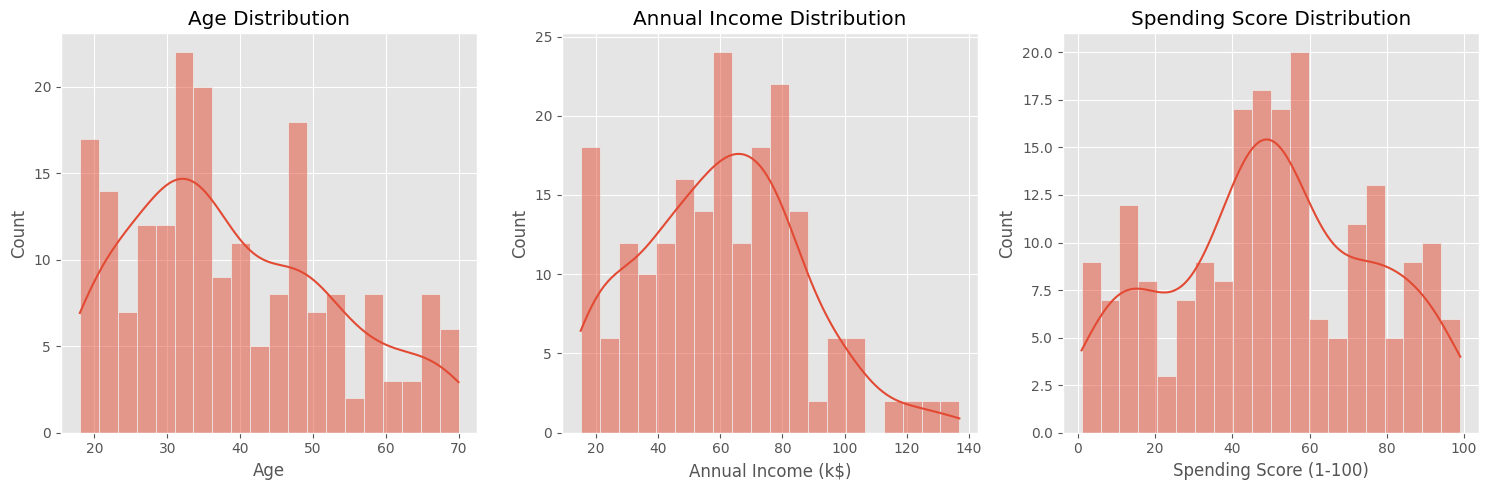

In [7]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")

plt.subplot(1,3,3)
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")

plt.tight_layout()
plt.show()

## Gender Distribution

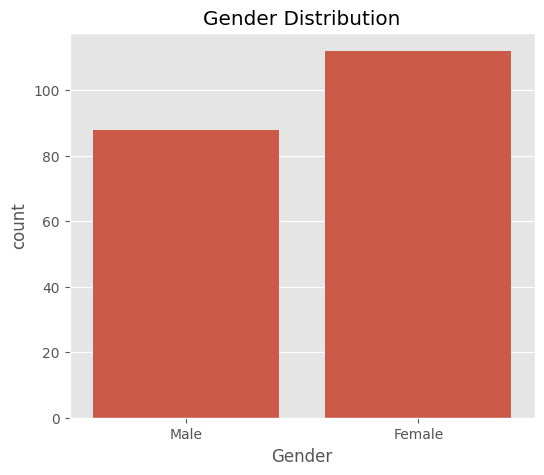

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()

## Annual Income vs Spending Score

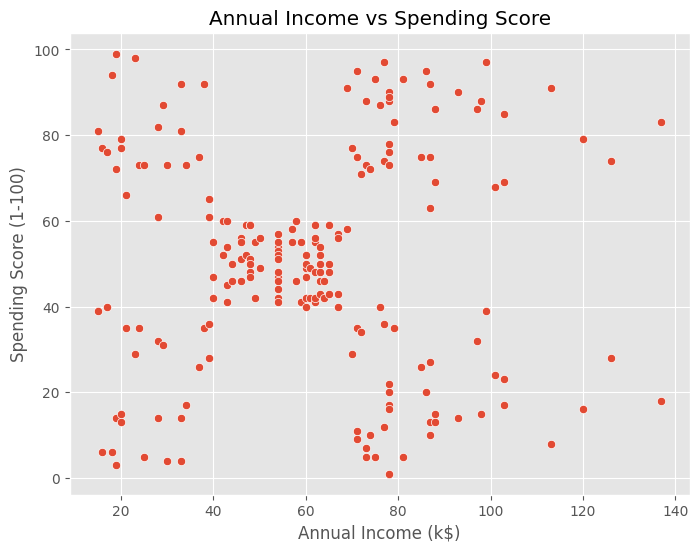

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")
plt.show()

## Correlation Matrix

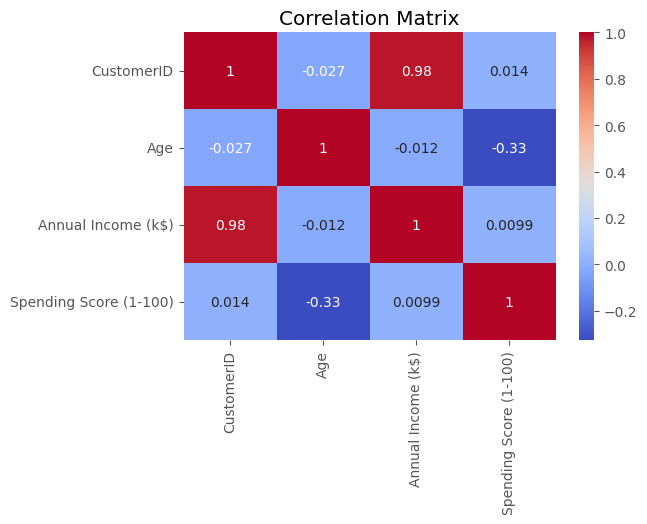

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Selecting Features for Clustering

We will use **Annual Income** and **Spending Score** because they provide the clearest customer purchasing patterns.

In [11]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Scaling

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Finding the Optimal Number of Clusters using the Elbow Method

In [13]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

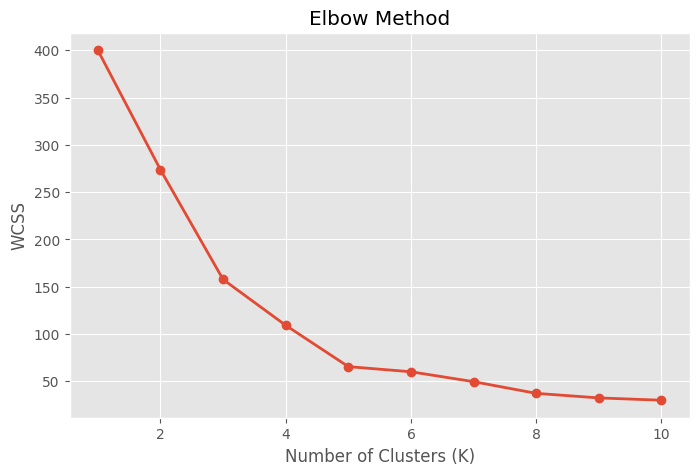

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

## Applying K-Means Clustering

Based on the Elbow Method, we choose **K = 5** as the optimal number of customer segments.

In [15]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

## Adding Cluster Labels to the Dataset

In [16]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Customer Segmentation Visualization

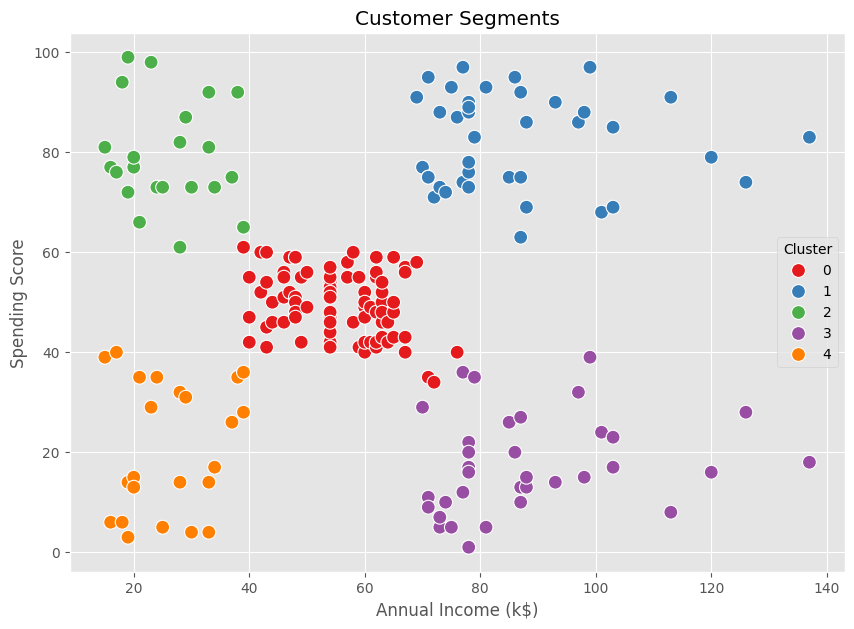

In [17]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend(title="Cluster")

plt.show()

## Cluster Centers

In [18]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=["Annual Income","Spending Score"]
)

centers_df

,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Number of Customers in Each Cluster

In [19]:
df["Cluster"].value_counts().sort_index()


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

## Business Recommendations

In [20]:
cluster_summary = df.groupby("Cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


# Business Insights

### Cluster 0
- Premium Customers
- High Income
- High Spending
- Recommendation: Offer VIP memberships and premium products.

### Cluster 1
- Budget Customers
- Low Income
- Low Spending
- Recommendation: Promote affordable products and discounts.

### Cluster 2
- High Income but Low Spending
- Recommendation: Target with personalized offers and loyalty programs.

### Cluster 3
- Average Customers
- Recommendation: Upsell products through seasonal promotions.

### Cluster 4
- Moderate Income with High Spending
- Recommendation: Reward with exclusive deals and cashback offers.

# Conclusion

This project successfully segmented customers into five distinct groups using K-Means Clustering.

Key achievements:

- Performed data cleaning and exploratory data analysis.
- Applied StandardScaler for feature scaling.
- Determined the optimal number of clusters using the Elbow Method.
- Built a K-Means clustering model.
- Visualized customer segments.
- Generated business recommendations for targeted marketing strategies.

This project demonstrates how unsupervised machine learning can help businesses improve customer targeting, increase customer satisfaction, and maximize revenue.